# 数据读取

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("D:\VsCodeProjects\Ecommerce_User_Analysis\data\cleaned_data.csv")
df.head()

<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
C:\Users\yivimc\AppData\Local\Temp\ipykernel_43352\1855169525.py:4: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  df = pd.read_csv("D:\VsCodeProjects\Ecommerce_User_Analysis\data\cleaned_data.csv")


,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,weekday
0,128078,4630672,2033408,pv,1512266009,2017-12-03 09:53:29,2017-12-03,9,Sunday
1,10035,3667432,1080785,pv,1511890180,2017-11-29 01:29:40,2017-11-29,1,Wednesday
2,109218,2403812,3430419,pv,1512232651,2017-12-03 00:37:31,2017-12-03,0,Sunday
3,106205,5150006,1165503,pv,1511855219,2017-11-28 15:46:59,2017-11-28,15,Tuesday
4,1002307,905583,2520377,pv,1511795200,2017-11-27 23:06:40,2017-11-27,23,Monday


# 各行为用户规模统计

In [8]:
pv_users = df[df["behavior_type"] == "pv"]["user_id"].nunique()
fav_users = df[df["behavior_type"] == "fav"]["user_id"].nunique()
cart_users = df[df["behavior_type"] == "cart"]["user_id"].nunique()
buy_users = df[df["behavior_type"] == "buy"]["user_id"].nunique()

print("PV:", pv_users)
print("FAV:", fav_users)
print("CART:", cart_users)
print("BUY:", buy_users)

PV: 676221
FAV: 48190
CART: 96281
BUY: 38697


# 构建转化漏斗表

In [9]:
funnel = pd.DataFrame(
    {
        "stage": ["PV", "FAV", "CART", "BUY"],
        "users": [pv_users, fav_users, cart_users, buy_users],
    }
)
funnel

,stage,users
0,PV,676221
1,FAV,48190
2,CART,96281
3,BUY,38697


# 计算整体转化率

In [10]:
funnel["overall_conversion"] = (funnel["users"] / pv_users * 100).round(2)
funnel

,stage,users,overall_conversion
0,PV,676221,100.00
1,FAV,48190,7.13
2,CART,96281,14.24
3,BUY,38697,5.72


# 计算阶段转化率

In [11]:
funnel["stage_conversion"] = [
    100,
    round(fav_users / pv_users * 100, 2),
    round(cart_users / fav_users * 100, 2),
    round(buy_users / cart_users * 100, 2),
]
funnel

,stage,users,overall_conversion,stage_conversion
0,PV,676221,100.00,100.00
1,FAV,48190,7.13,7.13
2,CART,96281,14.24,199.79
3,BUY,38697,5.72,40.19


# 漏斗可视化

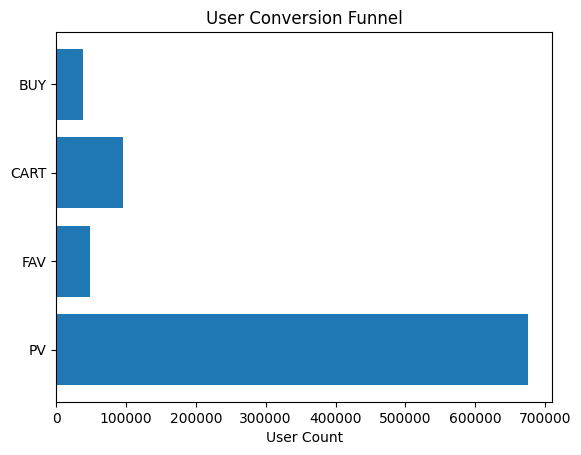

In [12]:
plt.Figure(figsize=(8,5))
plt.barh(funnel['stage'],funnel['users'])
plt.title("User Conversion Funnel")
plt.xlabel('User Count')
plt.savefig(r'D:\VsCodeProjects\Ecommerce_User_Analysis\figures\User_Conversion_Funnel.png',dpi=300,bbox_inches='tight')
plt.show()

# 业务洞察与优化建议

## 业务洞察

1. 浏览用户规模达到67.6万，而最终购买用户为3.87万，整体购买转化率约为5.72%，说明用户在浏览至成交过程中存在较大的流失空间。

2. 加购用户数量显著高于收藏用户数量，表明用户更倾向于将感兴趣商品直接加入购物车，而非通过收藏功能进行后续决策。

3. 购物车用户具有较高的购买潜力，约40%的加购用户最终完成购买，是平台最值得重点运营的人群。

## 优化建议

1. 优化商品详情页展示效果，提高商品主图质量、评价展示及卖点呈现能力，提升浏览用户的购买意愿。

2. 建立购物车召回机制，通过未付款提醒、限时优惠券及降价通知等方式促进加购用户完成购买。

3. 针对收藏及加购用户开展精准营销活动，通过个性化推荐和定向优惠策略提高转化率与复购率。